In [1]:
import hoda
import tensorly as tl
import mne
tl.set_backend('cupy')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_008()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
4200 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
4195,1,0,0
4196,1,0,0
4197,1,0,0
4198,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2015/2075018065.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(4200, 8, 26)

In [5]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler


bttda = BTTDA(
    n_blocks=16,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-20,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lobpcg',
        taper=False,
        extra_train_info=False,
        verbose=False,
       
    ),
    gs_params=dict(n_jobs=5),
    verbose=True,
    extra_train_info=True,
)

#%lprun -f bttda.fit bttda.fit(X,y)
%prun bttda.fit(X,y)

Fitting block 1/16...
Fitting block 2/16...
Fitting block 3/16...
Fitting block 4/16...
Fitting block 5/16...
Fitting block 6/16...
Fitting block 7/16...
Fitting block 8/16...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")


Fitting block 9/16...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")


Fitting block 10/16...
Fitting block 11/16...


...

/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")


Fitting block 15/16...


/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")
/project/src/hoda/hoda.py:216: UserWarning: lobpcg failed with error 'NoneType' object has no attribute 'ndim'
  warnings.warn(f"lobpcg failed with error {e}")


Fitting block 16/16...
 

         2751914 function calls (2693259 primitive calls) in 90.529 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     7230   74.764    0.010   74.764    0.010 {built-in method time.sleep}
     1968    1.644    0.001    2.283    0.001 _lobpcg.py:11(_cholesky)
    16296    1.008    0.000    1.019    0.000 {method 'mean' of 'cupy._core.core._ndarray_base' objects}
     1096    0.702    0.001    1.043    0.001 cov.py:103(ledoit_wolf_shrinkage)
     1936    0.600    0.000    6.085    0.003 _lobpcg.py:183(lobpcg)
    20067    0.551    0.000    0.556    0.000 {built-in method cupy._core.core.array}
       64    0.525    0.008    0.525    0.008 {built-in method cupy_backends.cuda.libs.cusolver.dgesvd}
        4    0.459    0.115    0.459    0.115 {built-in method cupy_backends.cuda.libs.nvrtc.compileProgram}
    12894    0.456    0.000    0.457    0.000 {method 'dot' of 'cupy._core.core._ndarray_base' objects}
     2128    0.454

In [6]:
bttda.train_info_


,score,rank,mse
block,,,
1,0.840069,"(8, 8)",5.699153e-11
2,0.853608,"(1, 1)",5.182714e-11
3,0.854616,"(1, 1)",4.734578e-11
4,0.853806,"(1, 1)",4.311806e-11
5,0.852157,"(1, 1)",4.313067e-11
6,0.853229,"(1, 1)",3.934220e-11
7,0.835927,"(1, 1)",3.936130e-11
8,0.835441,"(1, 1)",3.611106e-11
9,0.829192,"(8, 8)",3.966966e-11


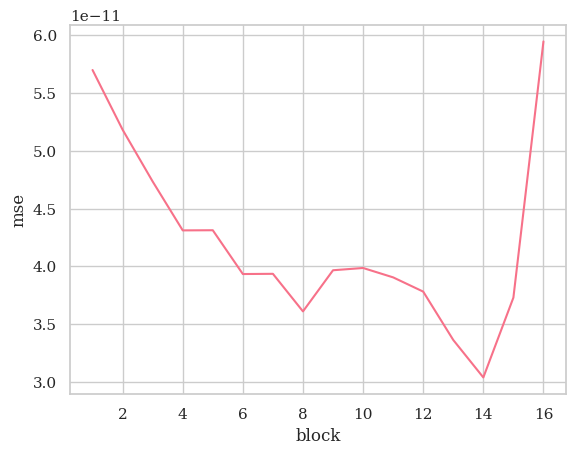

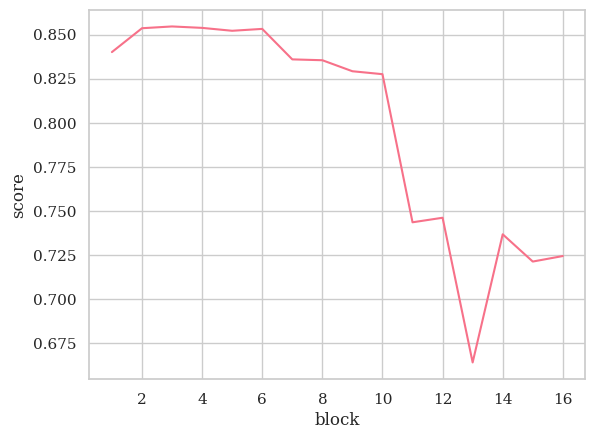

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=bttda.train_info_, x='block', y='mse')
plt.show()
sns.lineplot(data=bttda.train_info_, x='block', y='score')
plt.show()


In [8]:
Xt = bttda.transform(X)

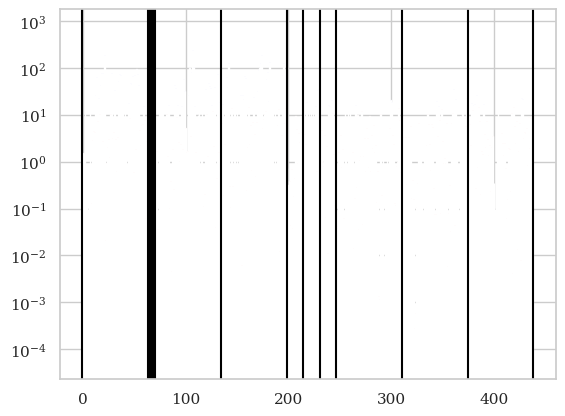

In [9]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b in bttda.blocks_:
    n_params+=math.prod(b.ml_rank_)
    plt.axvline(n_params-.5, color='black')


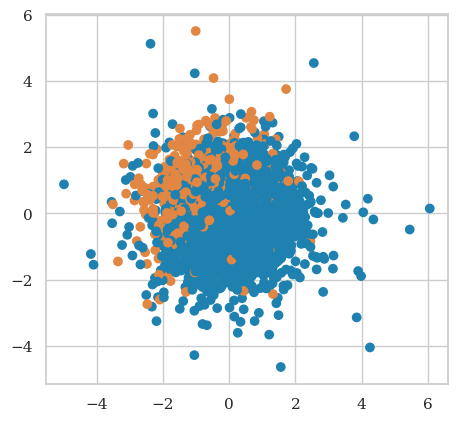

In [10]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [11]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


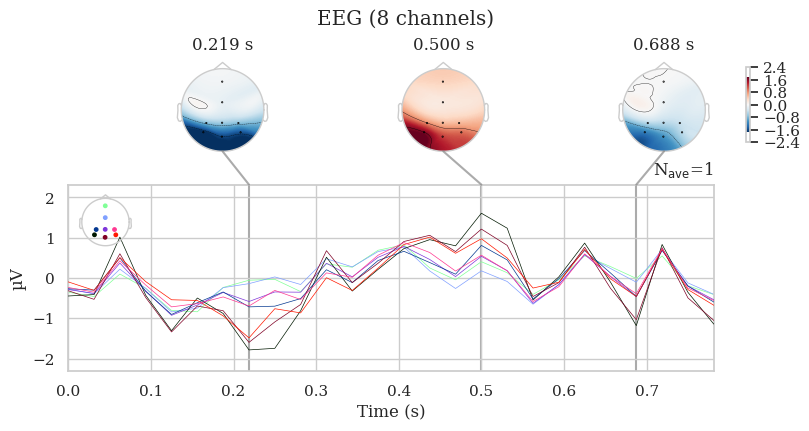

No projector specified for this dataset. Please consider the method self.add_proj.


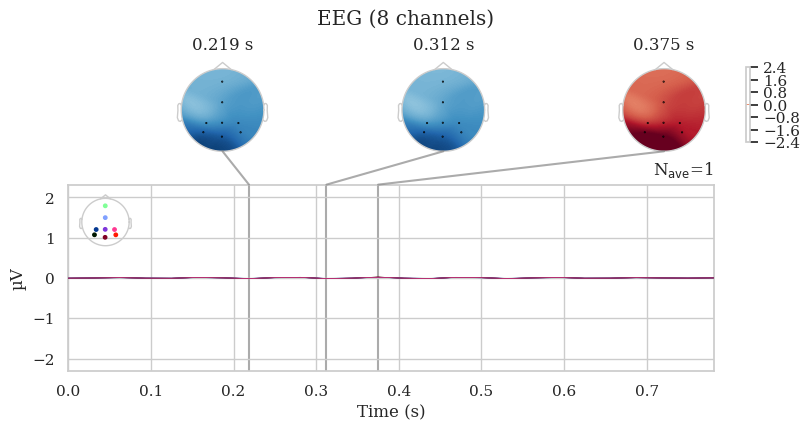

No projector specified for this dataset. Please consider the method self.add_proj.


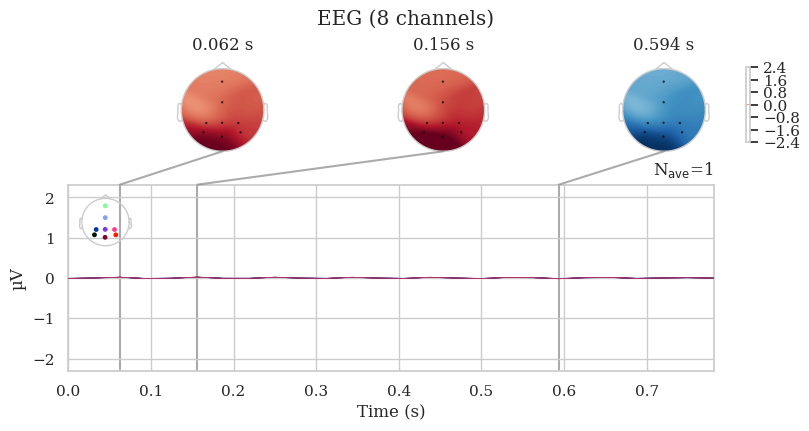

No projector specified for this dataset. Please consider the method self.add_proj.


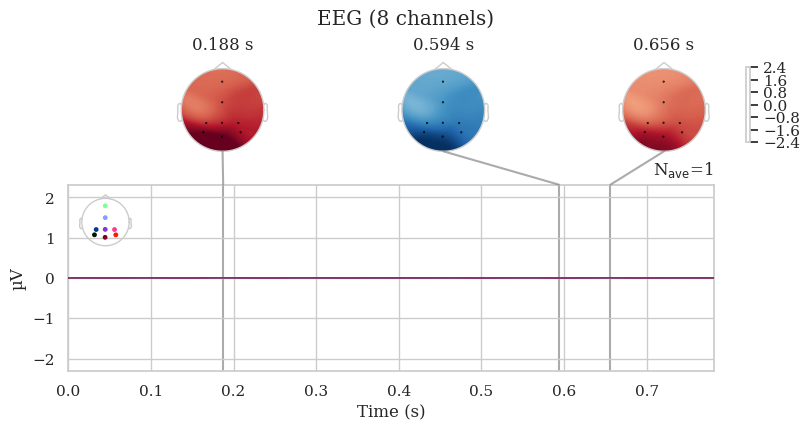

No projector specified for this dataset. Please consider the method self.add_proj.


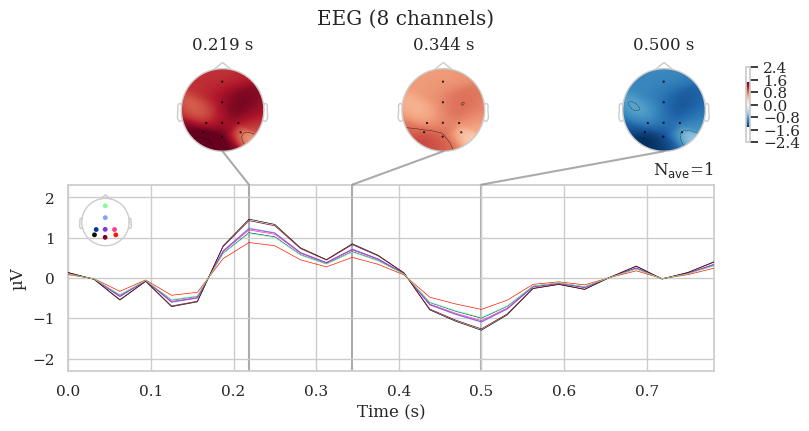

No projector specified for this dataset. Please consider the method self.add_proj.


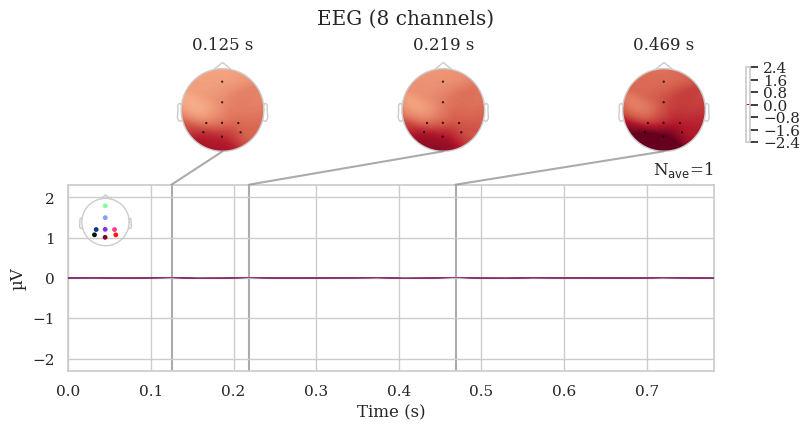

No projector specified for this dataset. Please consider the method self.add_proj.


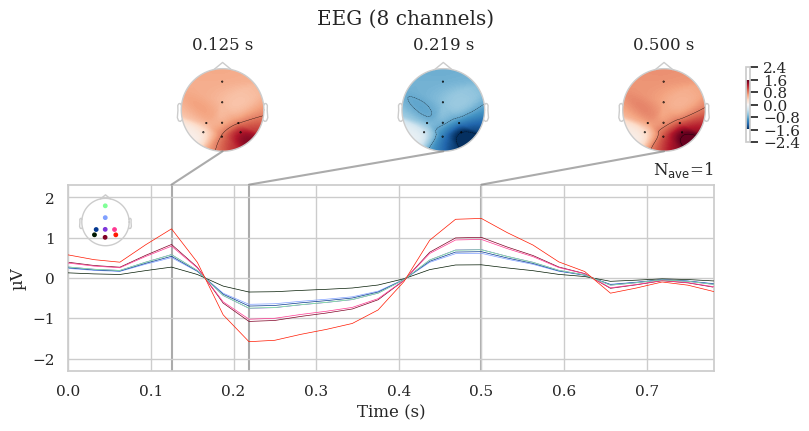

No projector specified for this dataset. Please consider the method self.add_proj.


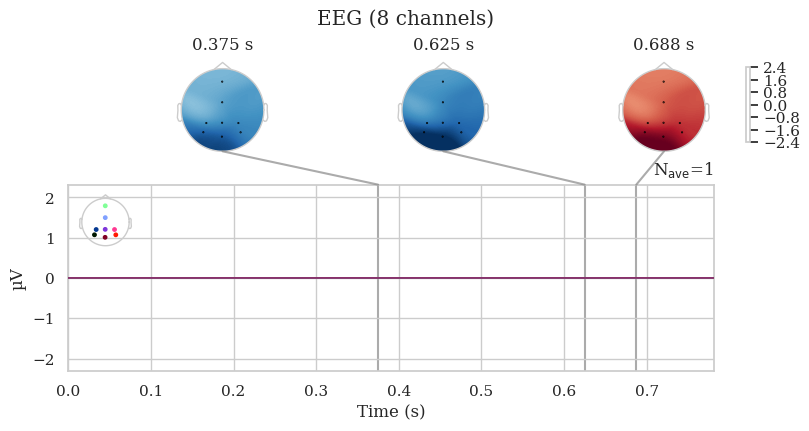

No projector specified for this dataset. Please consider the method self.add_proj.


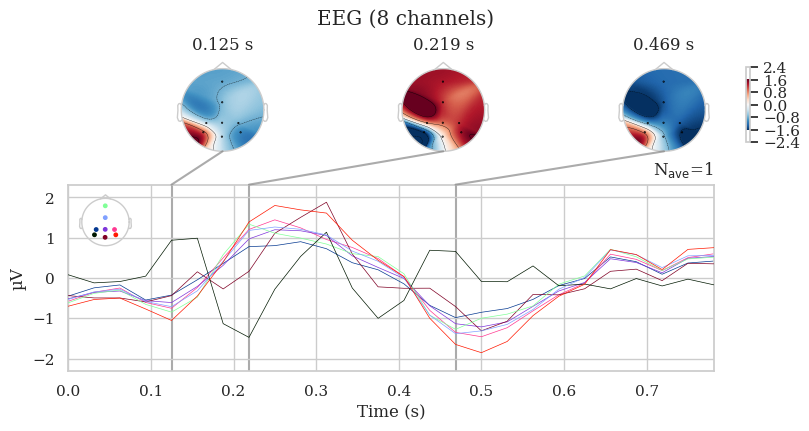

No projector specified for this dataset. Please consider the method self.add_proj.


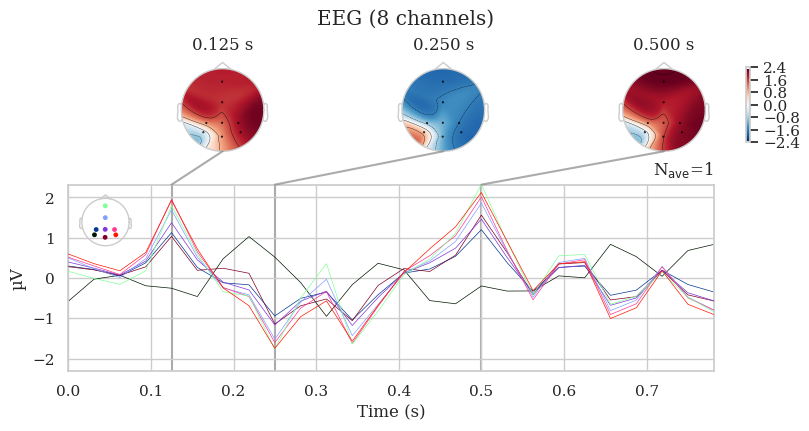

No projector specified for this dataset. Please consider the method self.add_proj.


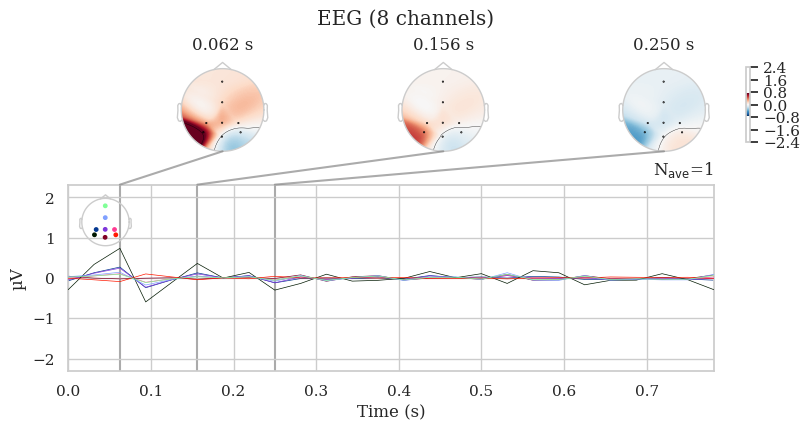

No projector specified for this dataset. Please consider the method self.add_proj.


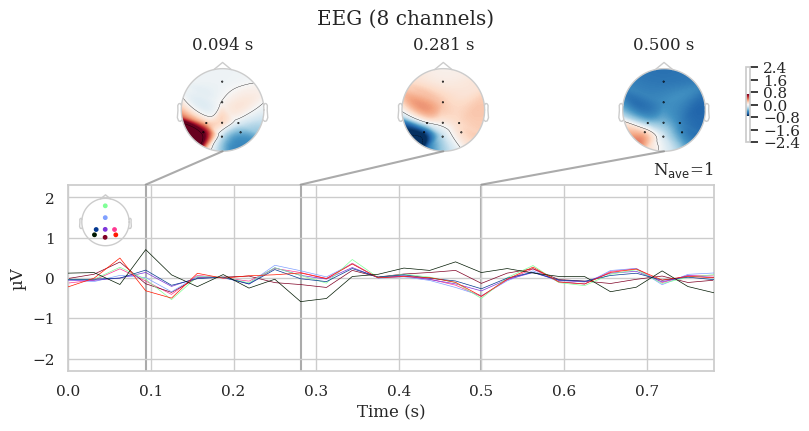

No projector specified for this dataset. Please consider the method self.add_proj.


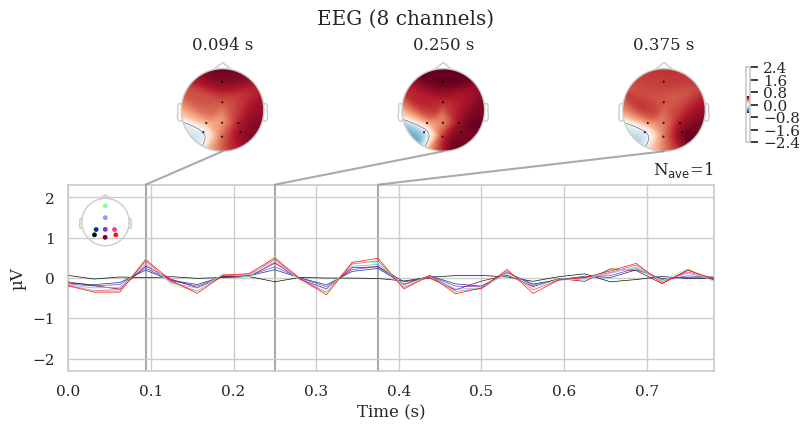

No projector specified for this dataset. Please consider the method self.add_proj.


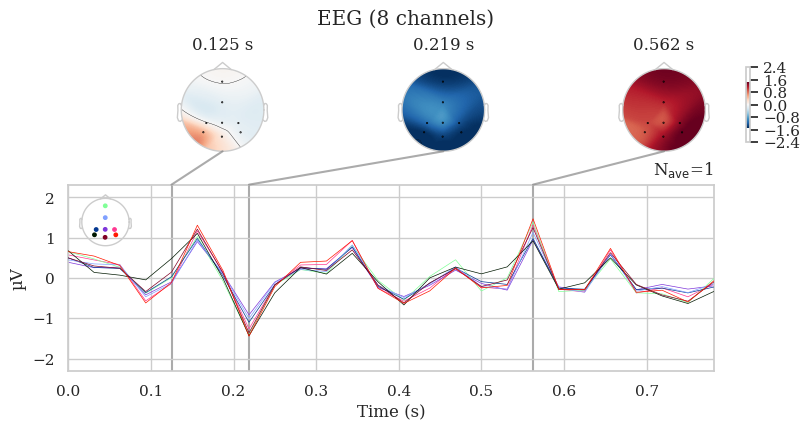

No projector specified for this dataset. Please consider the method self.add_proj.


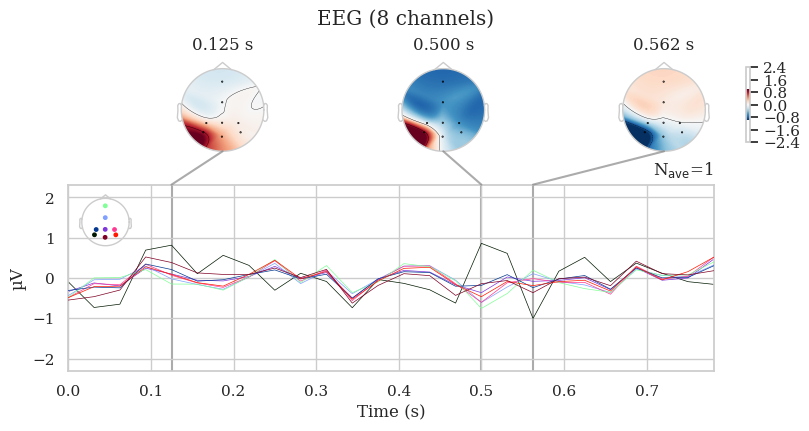

No projector specified for this dataset. Please consider the method self.add_proj.


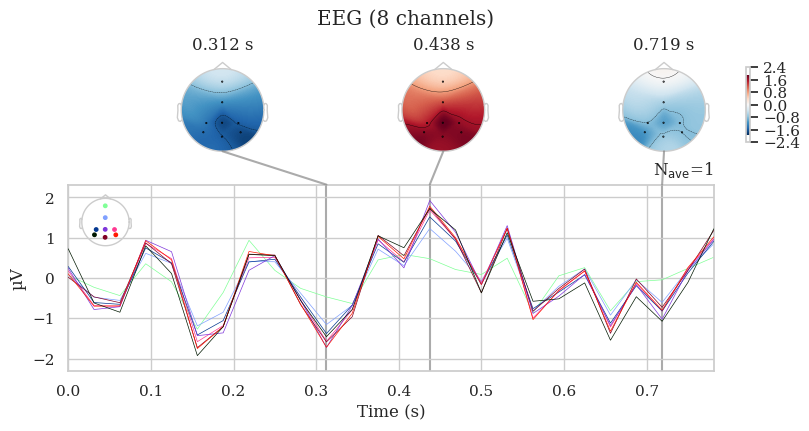

In [12]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [13]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


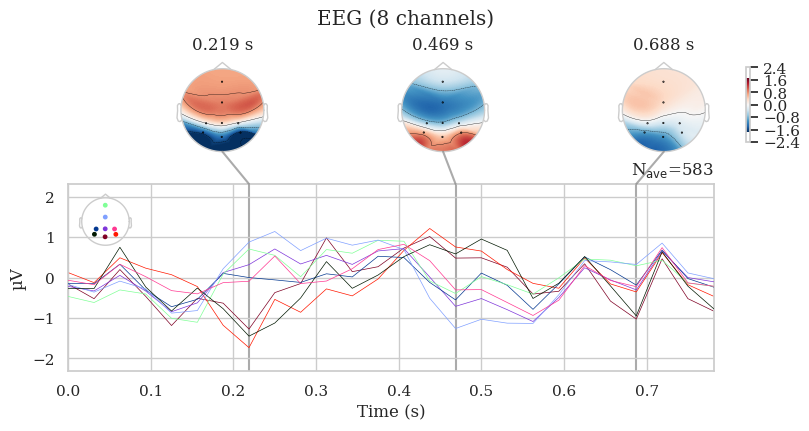

No projector specified for this dataset. Please consider the method self.add_proj.


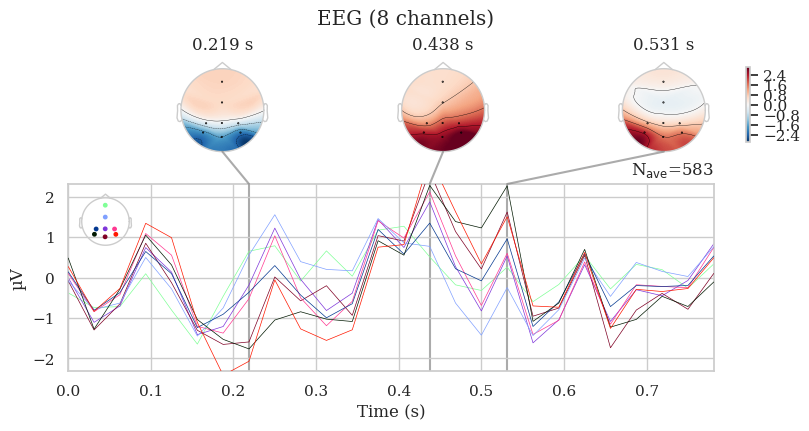

In [14]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


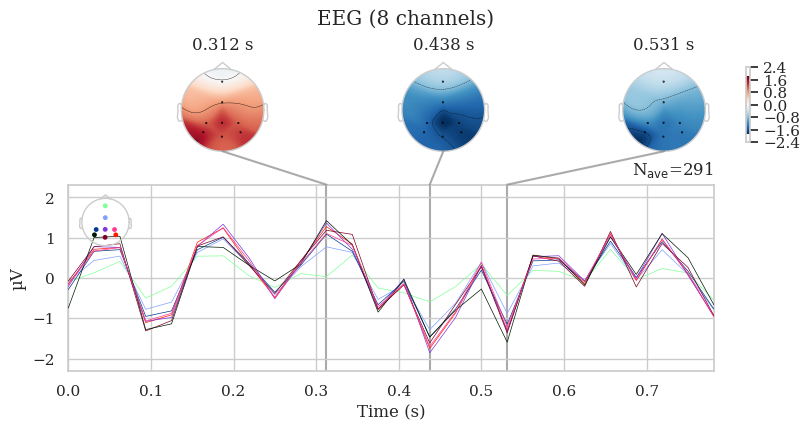

In [15]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)